In [1]:
import zipfile, os
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

with zipfile.ZipFile('/content/archive.zip', 'r') as zf:
  zf.extractall('/content/')

print("yes:", os.listdir('/content/yes')[:3])
print("no:", os.listdir('/content/no')[:3])

yes: ['Y186.jpg', 'Y81.jpg', 'Y157.JPG']
no: ['N2.JPG', 'no 96.jpg', 'no 92.jpg']


In [2]:
import shutil
import numpy as np
from sklearn.model_selection import train_test_split

# директории для train/test
os.makedirs('/content/train/yes', exist_ok=True)
os.makedirs('/content/train/no', exist_ok=True)
os.makedirs('/content/test/yes', exist_ok=True)
os.makedirs('/content/test/no', exist_ok=True)

yes_files = ['/content/yes/' + f for f in os.listdir('/content/yes')]
no_files = ['/content/no/' + f for f in os.listdir('/content/no')]

yes_train, yes_test = train_test_split(yes_files, test_size=0.2, random_state=42)
no_train, no_test = train_test_split(no_files, test_size=0.2, random_state=42)

# копируем файлы
for file_path in yes_train:
    shutil.copy(file_path, '/content/train/yes/')
for file_path in yes_test:
    shutil.copy(file_path, '/content/test/yes/')
for file_path in no_train:
    shutil.copy(file_path, '/content/train/no/')
for file_path in no_test:
    shutil.copy(file_path, '/content/test/no/')

print(f"train: yes - {len(yes_train)}, no - {len(no_train)}")
print(f"test: yes - {len(yes_test)}, no - {len(no_test)}")

train: yes - 124, no - 78
test: yes - 31, no - 20


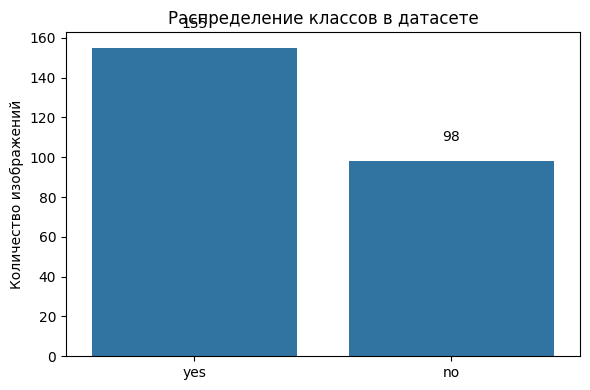

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.barplot(x=['yes', 'no'], y=[len(yes_files), len(no_files)])
plt.title('Распределение классов в датасете')
plt.ylabel('Количество изображений')
for i, v in enumerate([len(yes_files), len(no_files)]):
    plt.text(i, v+10, str(v), ha='center')
plt.tight_layout()

In [4]:
import torch
import torchvision
from torchvision import transforms, datasets

train_transform=transforms.Compose(
    [
        transforms.Resize((128,128)),
        transforms.RandomRotation(10),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
    ]
)

test_transform=transforms.Compose(
    [
        transforms.Resize((128,128)),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
    ]
)

train_dataset=datasets.ImageFolder('/content/train', transform=train_transform)
test_dataset=datasets.ImageFolder('/content/test', transform=test_transform)

for i in range(5):
  image, label=train_dataset[i]
  print(f'индекс {i}: класс {label}, изображение {image.shape}')

индекс 0: класс 0, изображение torch.Size([3, 128, 128])
индекс 1: класс 0, изображение torch.Size([3, 128, 128])
индекс 2: класс 0, изображение torch.Size([3, 128, 128])
индекс 3: класс 0, изображение torch.Size([3, 128, 128])
индекс 4: класс 0, изображение torch.Size([3, 128, 128])


In [5]:
from torch.utils.data import DataLoader

train_loader=DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader=DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f'всего классов: {len(train_dataset.classes)}')
print(f'train: {len(train_dataset)} изображений')
print(f'test: {len(test_dataset)} изображений')

всего классов: 2
train: 202 изображений
test: 51 изображений


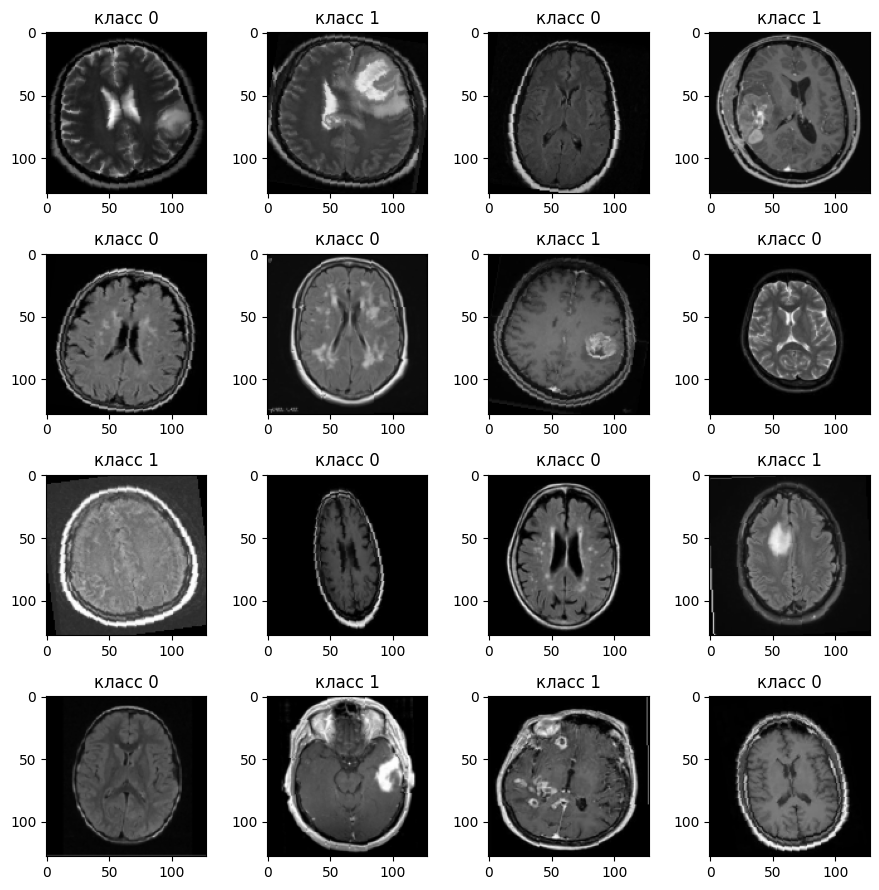

In [6]:
import numpy as np

images, labels = next(iter(train_loader))

fig, axes=plt.subplots(4,4, figsize=(9,9))
axes=axes.ravel()

for i in range(16):
  img=images[i].permute(1,2,0).numpy()

  img=0.5*img +0.5
  img=np.clip(img,0,1)

  axes[i].imshow(img)
  axes[i].set_title(f'класс {labels[i].item()}')

plt.tight_layout()

In [7]:
print(f"форма батча: {images.shape}")
print(f"мин: {images.min():.3f}, макс: {images.max():.3f}, среднее: {images.mean():.3f}")

форма батча: torch.Size([32, 3, 128, 128])
мин: -1.000, макс: 1.000, среднее: -0.582


In [8]:
from torch.nn import Sequential, ReLU, Dropout, Conv2d, MaxPool2d, Linear, CrossEntropyLoss,Flatten, BatchNorm2d
from torch import optim
from torchvision import models

model1=Sequential(
    Conv2d(3,32,kernel_size=3, padding=1), #[32,128,128]
    BatchNorm2d(32),
    ReLU(),
    MaxPool2d(2),#[32, 64, 64]

    Conv2d(32, 64, kernel_size=3, padding=1), #[64,64,64]
    BatchNorm2d(64),
    ReLU(),
    MaxPool2d(2),#[64,32,32]

    Conv2d(64, 128, kernel_size=3, padding=1),#[128,32,32]
    BatchNorm2d(128),
    ReLU(),
    MaxPool2d(2),#[128,16,16]

    Flatten(),
    Linear(128*16*16,256),
    ReLU(),
    Linear(256,2)
)

model2=Sequential(
    Conv2d(3,16,kernel_size=3, padding=1),
    BatchNorm2d(16),
    ReLU(),
    MaxPool2d(2),
    Dropout(0.1),

    Conv2d(16,32,kernel_size=3, padding=1),
    BatchNorm2d(32),
    ReLU(),
    MaxPool2d(2),
    Dropout(0.2),

    Conv2d(32,64, kernel_size=3, padding=1),
    BatchNorm2d(64),
    ReLU(),
    MaxPool2d(2),
    Dropout(0.2),

    Flatten(),
    Linear(64*16*16,128),
    ReLU(),
    Dropout(0.3),
    Linear(128,2)
)

model3=models.resnet18(pretrained=True)
model3.fc=Linear(model3.fc.in_features, 2)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 163MB/s]


эпоха 1: loss = 7.882, accuracy = 60.89%
эпоха 2: loss = 2.973, accuracy = 64.36%
эпоха 3: loss = 0.902, accuracy = 74.75%
эпоха 4: loss = 0.680, accuracy = 81.19%
эпоха 5: loss = 0.899, accuracy = 73.27%
эпоха 6: loss = 1.161, accuracy = 73.76%
эпоха 7: loss = 1.462, accuracy = 72.77%
эпоха 8: loss = 1.326, accuracy = 75.74%
эпоха 9: loss = 0.735, accuracy = 79.70%
эпоха 10: loss = 0.351, accuracy = 87.62%


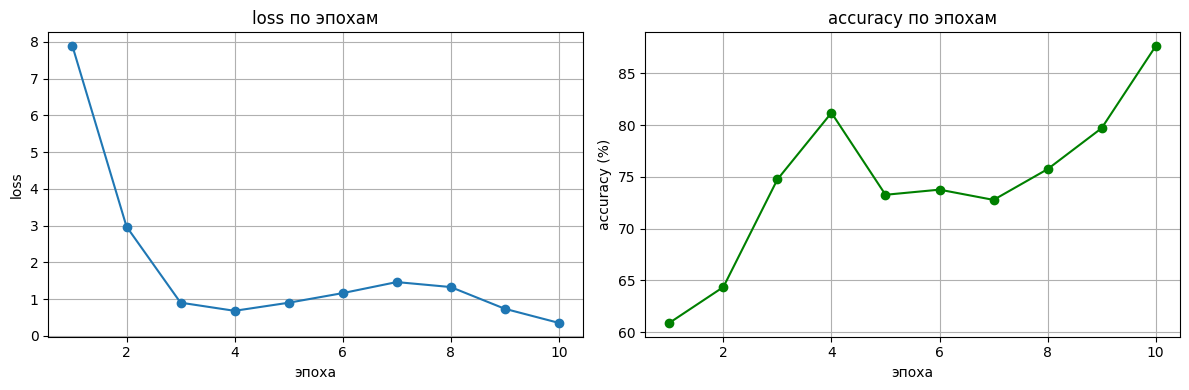

([7.8822246960231235,
  2.9727246591023038,
  0.9015585737568992,
  0.6795029320887157,
  0.8993454618113381,
  1.1610766904694694,
  1.4616489240101405,
  1.3263319730758667,
  0.7352178772645337,
  0.3509267738887242],
 [60.89108910891089,
  64.35643564356435,
  74.75247524752476,
  81.1881188118812,
  73.26732673267327,
  73.76237623762376,
  72.77227722772277,
  75.74257425742574,
  79.70297029702971,
  87.62376237623762])

In [9]:
loss_f=CrossEntropyLoss()

optimizer1=optim.Adam(model1.parameters())
optimizer2=optim.Adam(model2.parameters())
optimizer3=optim.Adam(model3.parameters())

def train_model(model, optimizer, loss_f, train_loader, epochs):
    train_losses=[]
    train_accs=[]
    best_acc=0

    for epoch in range(epochs):
        model.train()
        cor=0
        tot=0
        loss_ep=0

        for x_tr, y_tr in train_loader:
            y_pred_raw =model(x_tr)
            loss = loss_f(y_pred_raw, y_tr)
            loss_ep+=loss.item()

            y_pred=torch.max(y_pred_raw, 1)[1]
            cor+=(y_pred == y_tr).sum().item()
            tot+=len(y_tr)

            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

        current_loss = loss_ep/len(train_loader)
        current_acc = cor/tot*100

        train_losses.append(current_loss)
        train_accs.append(current_acc)

        print(f'эпоха {epoch+1}: loss = {current_loss:.3f}, accuracy = {current_acc:.2f}%')

        if current_acc>best_acc:
            best_acc = current_acc
            torch.save(model.state_dict(), f'best_model_{epoch+1}.pth')

    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.plot(range(1, epochs+1), train_losses, marker='o')
    plt.title('loss по эпохам')
    plt.xlabel('эпоха')
    plt.ylabel('loss')
    plt.grid(True)

    plt.subplot(1,2,2)
    plt.plot(range(1, epochs+1), train_accs, marker='o', color='green')
    plt.title('accuracy по эпохам')
    plt.xlabel('эпоха')
    plt.ylabel('accuracy (%)')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    return train_losses, train_accs


train_model(model1,optimizer1, loss_f, train_loader, 10)

эпоха 1: loss = 2.886, accuracy = 56.93%
эпоха 2: loss = 1.616, accuracy = 66.34%
эпоха 3: loss = 1.112, accuracy = 70.79%
эпоха 4: loss = 0.495, accuracy = 75.74%
эпоха 5: loss = 0.525, accuracy = 72.77%
эпоха 6: loss = 0.486, accuracy = 79.21%
эпоха 7: loss = 0.424, accuracy = 82.67%
эпоха 8: loss = 0.414, accuracy = 81.68%
эпоха 9: loss = 0.422, accuracy = 80.69%
эпоха 10: loss = 0.360, accuracy = 85.15%


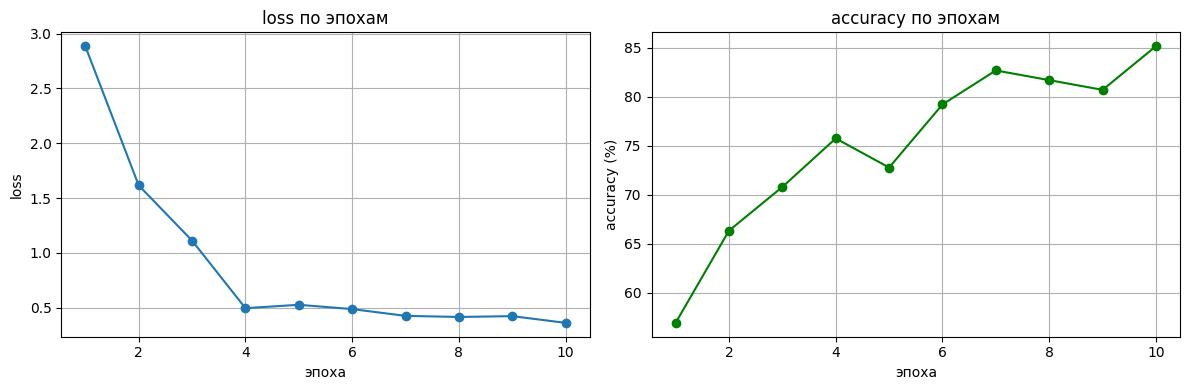

([2.8863022327423096,
  1.6158986943108695,
  1.111572959593364,
  0.4947548806667328,
  0.5253996551036835,
  0.48601914729390827,
  0.424320536000388,
  0.41435286828449797,
  0.42191395589283537,
  0.36027382739952635],
 [56.930693069306926,
  66.33663366336634,
  70.79207920792079,
  75.74257425742574,
  72.77227722772277,
  79.20792079207921,
  82.67326732673267,
  81.68316831683168,
  80.6930693069307,
  85.14851485148515])

In [10]:
train_model(model2,optimizer2,loss_f, train_loader,10)

эпоха 1: loss = 0.775, accuracy = 76.24%
эпоха 2: loss = 0.583, accuracy = 82.67%
эпоха 3: loss = 0.342, accuracy = 85.15%
эпоха 4: loss = 0.202, accuracy = 92.57%
эпоха 5: loss = 0.074, accuracy = 97.52%
эпоха 6: loss = 0.053, accuracy = 97.03%
эпоха 7: loss = 0.011, accuracy = 100.00%
эпоха 8: loss = 0.004, accuracy = 100.00%
эпоха 9: loss = 0.004, accuracy = 100.00%
эпоха 10: loss = 0.003, accuracy = 100.00%


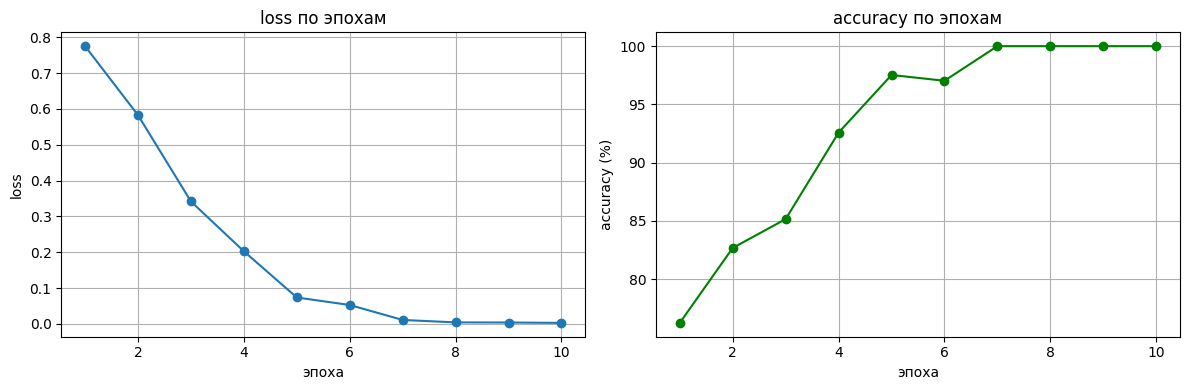

([0.7753370766128812,
  0.5825623082263129,
  0.3416242450475693,
  0.2024481605206217,
  0.07353834688131299,
  0.052561523259750435,
  0.01076651261454182,
  0.004028807261160442,
  0.0036417105667559163,
  0.0026146355168228702],
 [76.23762376237624,
  82.67326732673267,
  85.14851485148515,
  92.57425742574257,
  97.52475247524752,
  97.02970297029702,
  100.0,
  100.0,
  100.0,
  100.0])

In [11]:
train_model(model3,optimizer3, loss_f, train_loader,10)

In [18]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

def test_model(model, test_loader, model_name="model"):
    model.eval()
    cor = 0
    tot = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x_te, y_te in test_loader:
            y_pred_raw = model(x_te)
            y_pred = torch.max(y_pred_raw, 1)[1]

            cor += (y_pred == y_te).sum().item()
            tot += len(y_te)

            all_preds.extend(y_pred.numpy())
            all_labels.extend(y_te.numpy())

    accuracy = cor/tot*100
    print(f'{model_name} accuracy: {accuracy:.2f}%')

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=['no', 'yes'], yticklabels=['no', 'yes'])
    plt.title(f'confusion matrix: {model_name}')
    plt.ylabel('true')
    plt.xlabel('predicted')
    plt.show()
    plt.tight_layout()

    print("\nclassification Report:")
    print(classification_report(all_labels, all_preds, target_names=['no', 'yes']))

    return accuracy

model 1 (simple) accuracy: 70.59%


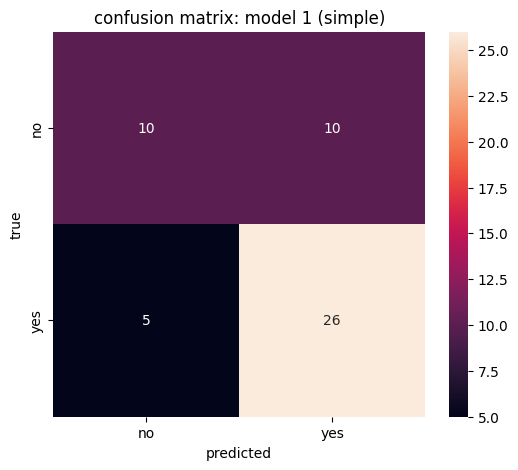


classification Report:
              precision    recall  f1-score   support

          no       0.67      0.50      0.57        20
         yes       0.72      0.84      0.78        31

    accuracy                           0.71        51
   macro avg       0.69      0.67      0.67        51
weighted avg       0.70      0.71      0.70        51



70.58823529411765

<Figure size 640x480 with 0 Axes>

In [19]:
test_model(model1,test_loader, 'model 1 (simple)')

model 2 (dropout) accuracy: 70.59%


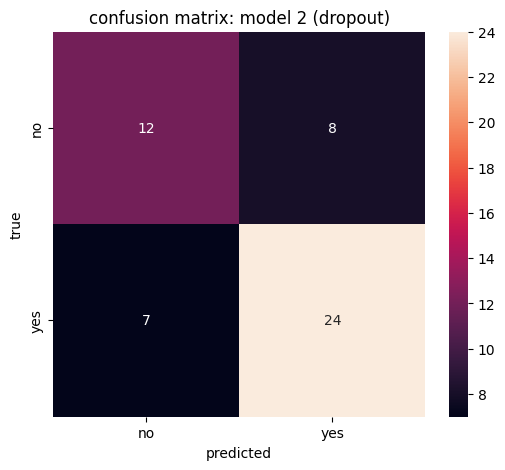


classification Report:
              precision    recall  f1-score   support

          no       0.63      0.60      0.62        20
         yes       0.75      0.77      0.76        31

    accuracy                           0.71        51
   macro avg       0.69      0.69      0.69        51
weighted avg       0.70      0.71      0.70        51



70.58823529411765

<Figure size 640x480 with 0 Axes>

In [20]:
test_model(model2,test_loader, 'model 2 (dropout)')

model 3 (ResNet18) accuracy: 88.24%


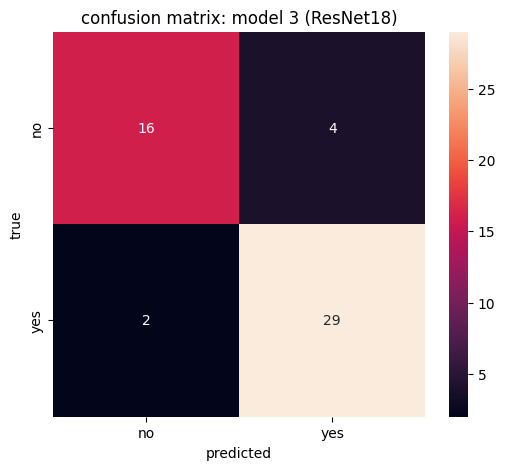


classification Report:
              precision    recall  f1-score   support

          no       0.89      0.80      0.84        20
         yes       0.88      0.94      0.91        31

    accuracy                           0.88        51
   macro avg       0.88      0.87      0.87        51
weighted avg       0.88      0.88      0.88        51



88.23529411764706

<Figure size 640x480 with 0 Axes>

In [21]:
test_model(model3,test_loader, 'model 3 (ResNet18)')